# Ensembles — Category Recap

> **Goal:** combine many models so the whole is more accurate than any part.

This notebook ties together the three ensemble notebooks
and shows how each strategy attacks a different part of the bias–variance budget.

| Strategy | Attacks | Base learner |
|---|---|---|
| Bagging | **variance** | high-variance (deep trees) |
| Boosting | **bias** | high-bias (stumps) |
| Stacking | **both, via diversity** | several different models |

## Cheat-sheet — three families of ensemble methods

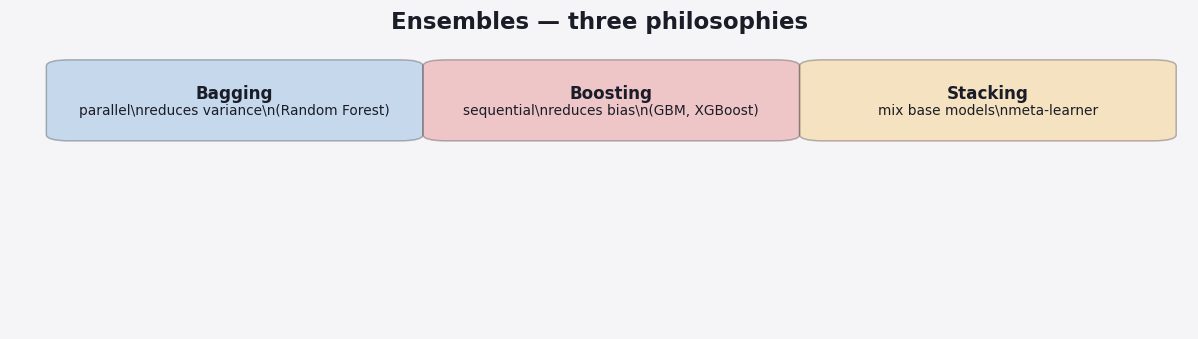

In [1]:
# (schematic — drawn from smooth curves, not measured)
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyArrow, FancyBboxPatch, Ellipse, Rectangle, Circle, FancyArrowPatch
plt.rcParams.update({
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'legend.facecolor':'#ffffff','legend.edgecolor':'#c8ccd4','figure.dpi':110,
})
P = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']
fig, ax = plt.subplots(figsize=(11, 3.2)); ax.axis('off')
ax.text(0.5, 0.96, 'Ensembles — three philosophies', ha='center', fontsize=15, weight='bold')
items = [('Bagging', 'parallel\\nreduces variance\\n(Random Forest)'), ('Boosting', 'sequential\\nreduces bias\\n(GBM, XGBoost)'), ('Stacking', 'mix base models\\nmeta-learner')]
for k, (name, blurb) in enumerate(items):
    r, c = divmod(k, 3)
    x = 0.05 + c*0.32; y = 0.82 - r*0.30
    ax.add_patch(FancyBboxPatch((x, y-0.20), 0.28, 0.22, boxstyle='round,pad=0.02',
                                facecolor=P[k % len(P)], alpha=0.30, edgecolor='#1a1d27'))
    ax.text(x+0.14, y-0.04, name, ha='center', va='top', fontsize=11, weight='bold')
    ax.text(x+0.14, y-0.10, blurb, ha='center', va='top', fontsize=9, wrap=True)
ax.set_xlim(0,1); ax.set_ylim(0,1); plt.tight_layout(); plt.show()


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import warnings; warnings.filterwarnings('ignore')

PLT_STYLE = {
    'figure.facecolor':'#f5f5f7','axes.facecolor':'#ffffff','axes.edgecolor':'#c8ccd4',
    'axes.labelcolor':'#1a1d27','axes.titlecolor':'#1a1d27','xtick.color':'#2a2e3a',
    'ytick.color':'#2a2e3a','grid.color':'#e0e3ea','grid.linestyle':'--','grid.alpha':0.5,
    'text.color':'#1a1d27','font.family':'DejaVu Sans','axes.titlesize':14,'axes.labelsize':12,
    'xtick.labelsize':10,'ytick.labelsize':10,'legend.fontsize':10,'legend.facecolor':'#ffffff',
    'legend.edgecolor':'#c8ccd4','figure.dpi':110,
}
plt.rcParams.update(PLT_STYLE)
PALETTE = ['#5b9bd5','#e05c5c','#f4b942','#7ecba1','#56b6c2','#c678dd','#888fa5','#d68a3c']


---
## Comparison

| Property | Single tree | Bagging | Boosting | Stacking |
|---|---|---|---|---|
| Reduces bias | ❌ | ❌ | ✅ | ✅ |
| Reduces variance | ❌ | ✅ | partial | partial |
| Parallel training | n/a | ✅ | ❌ | partial |
| Sensitive to noisy labels | ❌ | ✅ robust | ❌ overfits noise | partial |
| Out-of-the-box accuracy | low | medium | high | highest |
| Tuning required | low | low | high | medium |
| Interpretability | ✅ | ❌ | ❌ | ❌ |

---
## Decision rule

In [ ]:
from IPython.display import SVG, display
_svg = """\
<svg xmlns="http://www.w3.org/2000/svg" viewBox="0 0 700 310" width="700" height="310"
     style="font-family:'DejaVu Sans',sans-serif;background:#f5f5f7;border-radius:8px;">
  <line x1="350" y1="57" x2="128" y2="100" stroke="#c8ccd4" stroke-width="1.8"/>
  <line x1="350" y1="57" x2="515" y2="100" stroke="#c8ccd4" stroke-width="1.8"/>
  <text x="224" y="73" text-anchor="middle" font-size="11" font-weight="bold" fill="#5b9bd5">Yes</text>
  <text x="444" y="73" text-anchor="middle" font-size="11" font-weight="bold" fill="#e05c5c">No</text>
  <rect x="90" y="15" width="520" height="42" rx="6" fill="#5b9bd5" fill-opacity="0.15" stroke="#5b9bd5" stroke-width="1.5"/>
  <text x="350" y="32" text-anchor="middle" font-size="12" fill="#1a1d27">Base model already low-bias</text>
  <text x="350" y="48" text-anchor="middle" font-size="12" fill="#1a1d27">(deep tree, kNN)?</text>
  <rect x="10" y="100" width="236" height="42" rx="6" fill="#7ecba1" fill-opacity="0.25" stroke="#7ecba1" stroke-width="1.5"/>
  <text x="128" y="117" text-anchor="middle" font-size="12" fill="#1a1d27">Bagging</text>
  <text x="128" y="133" text-anchor="middle" font-size="10" fill="#555b6e">(Random Forest)</text>
  <rect x="397" y="100" width="236" height="42" rx="6" fill="#f4b942" fill-opacity="0.25" stroke="#f4b942" stroke-width="1.5"/>
  <text x="515" y="117" text-anchor="middle" font-size="12" fill="#1a1d27">Boosting</text>
  <text x="515" y="133" text-anchor="middle" font-size="10" fill="#555b6e">(GBM, XGBoost, LightGBM)</text>
  <line x1="5" y1="158" x2="695" y2="158" stroke="#c8ccd4" stroke-width="1" stroke-dasharray="5 3"/>
  <line x1="350" y1="212" x2="128" y2="255" stroke="#c8ccd4" stroke-width="1.8"/>
  <text x="226" y="237" text-anchor="middle" font-size="11" font-weight="bold" fill="#5b9bd5">Yes</text>
  <rect x="90" y="170" width="520" height="42" rx="6" fill="#5b9bd5" fill-opacity="0.15" stroke="#5b9bd5" stroke-width="1.5"/>
  <text x="350" y="187" text-anchor="middle" font-size="12" fill="#1a1d27">Multiple diverse models tuned</text>
  <text x="350" y="203" text-anchor="middle" font-size="12" fill="#1a1d27">&#x2014; do they disagree?</text>
  <rect x="10" y="255" width="236" height="42" rx="6" fill="#c678dd" fill-opacity="0.25" stroke="#c678dd" stroke-width="1.5"/>
  <text x="128" y="272" text-anchor="middle" font-size="12" fill="#1a1d27">Stacking</text>
  <text x="128" y="288" text-anchor="middle" font-size="10" fill="#555b6e">(&#x2248; 0.5&#x2013;1% extra)</text>
</svg>"""
display(SVG(_svg))

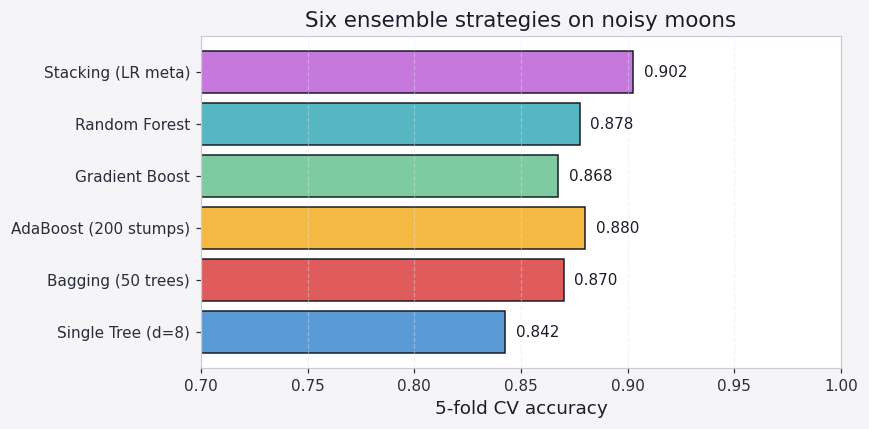

In [3]:
from sklearn.datasets import make_moons
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.ensemble import (BaggingClassifier, AdaBoostClassifier,
                               GradientBoostingClassifier, StackingClassifier,
                               RandomForestClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_score

X, y = make_moons(n_samples=400, noise=0.30, random_state=0)

models = {
    'Single Tree (d=8)': DecisionTreeClassifier(max_depth=8, random_state=0),
    'Bagging (50 trees)': BaggingClassifier(
        DecisionTreeClassifier(max_depth=8, random_state=0),
        n_estimators=50, random_state=0),
    'AdaBoost (200 stumps)': AdaBoostClassifier(
        DecisionTreeClassifier(max_depth=1), n_estimators=200, random_state=0),
    'Gradient Boost': GradientBoostingClassifier(
        n_estimators=200, max_depth=3, learning_rate=0.05, random_state=0),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=0),
    'Stacking (LR meta)': StackingClassifier(
        estimators=[('lr', LogisticRegression()), ('svm', SVC(probability=True)),
                    ('knn', KNeighborsClassifier(n_neighbors=15))],
        final_estimator=LogisticRegression()),
}

scores = {n: cross_val_score(m, X, y, cv=5).mean() for n, m in models.items()}

fig, ax = plt.subplots(figsize=(8, 4))
names, vals = zip(*scores.items())
bars = ax.barh(names, vals, color=PALETTE[:len(names)], edgecolor='#1a1d27')
for b, v in zip(bars, vals):
    ax.text(v+0.005, b.get_y()+b.get_height()/2, f'{v:.3f}', va='center', fontsize=10)
ax.set_xlim(0.7, 1.0)
ax.set_xlabel('5-fold CV accuracy')
ax.set_title('Six ensemble strategies on noisy moons')
ax.grid(True, axis='x', alpha=0.4)
plt.tight_layout()
plt.show()


---
## Reading the bars

- **Single tree** is the floor — it overfits the noise.
- **Bagging** removes most of that variance; Random Forest squeezes a bit more by also de-correlating the trees.
- **Boosting** (AdaBoost / GBM) reaches the highest accuracy because it actively fights bias.
- **Stacking** with three diverse weak learners can match boosting — but only if the base models truly disagree.

> Lesson: pick the ensemble that targets your **dominant** error component.
> Don't bag a low-variance model; don't boost a high-variance one without strong regularisation.
